Epoch 1, Loss: 3.4400
Epoch 2, Loss: 2.3908
Epoch 3, Loss: 2.5355
Epoch 4, Loss: 1.8428
Epoch 5, Loss: 1.5130
Epoch 6, Loss: 1.6560
Epoch 7, Loss: 1.4705
Epoch 8, Loss: 1.6033
Epoch 9, Loss: 1.5500
Epoch 10, Loss: 1.3473
Epoch 11, Loss: 1.5005
Epoch 12, Loss: 1.3611
Epoch 13, Loss: 1.3069
Epoch 14, Loss: 1.3190
Epoch 15, Loss: 1.2399
Epoch 16, Loss: 1.3046
Epoch 17, Loss: 1.2764
Epoch 18, Loss: 1.2166
Epoch 19, Loss: 1.2776
Epoch 20, Loss: 1.1344
Epoch 21, Loss: 1.1441
Epoch 22, Loss: 1.5150
Epoch 23, Loss: 1.2040
Epoch 24, Loss: 1.0932
Epoch 25, Loss: 1.0882
Epoch 26, Loss: 1.0940
Epoch 27, Loss: 1.0181
Epoch 28, Loss: 1.0818
Epoch 29, Loss: 1.0913
Epoch 30, Loss: 1.1005
Epoch 31, Loss: 1.4010
Epoch 32, Loss: 1.2947
Epoch 33, Loss: 1.0641
Epoch 34, Loss: 0.9907
Epoch 35, Loss: 0.9346
Epoch 36, Loss: 1.0659
Epoch 37, Loss: 1.0357
Epoch 38, Loss: 1.0149
Epoch 39, Loss: 1.0154
Epoch 40, Loss: 1.0320
Epoch 41, Loss: 1.0265
Epoch 42, Loss: 0.9156
Epoch 43, Loss: 1.2321
Epoch 44, Loss: 0.95

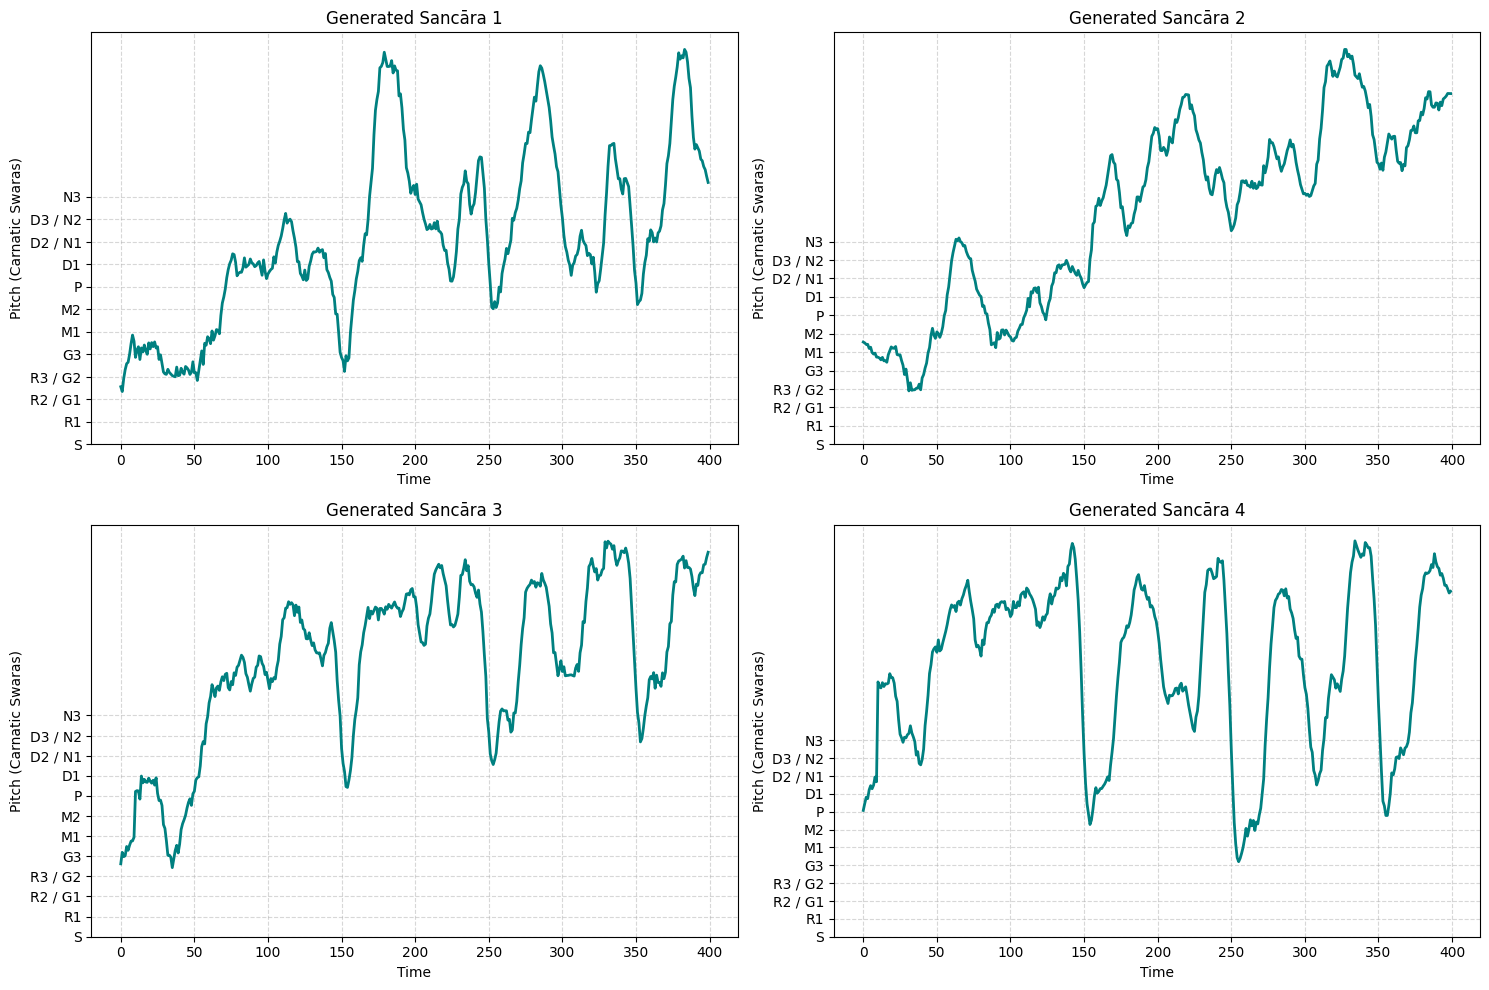

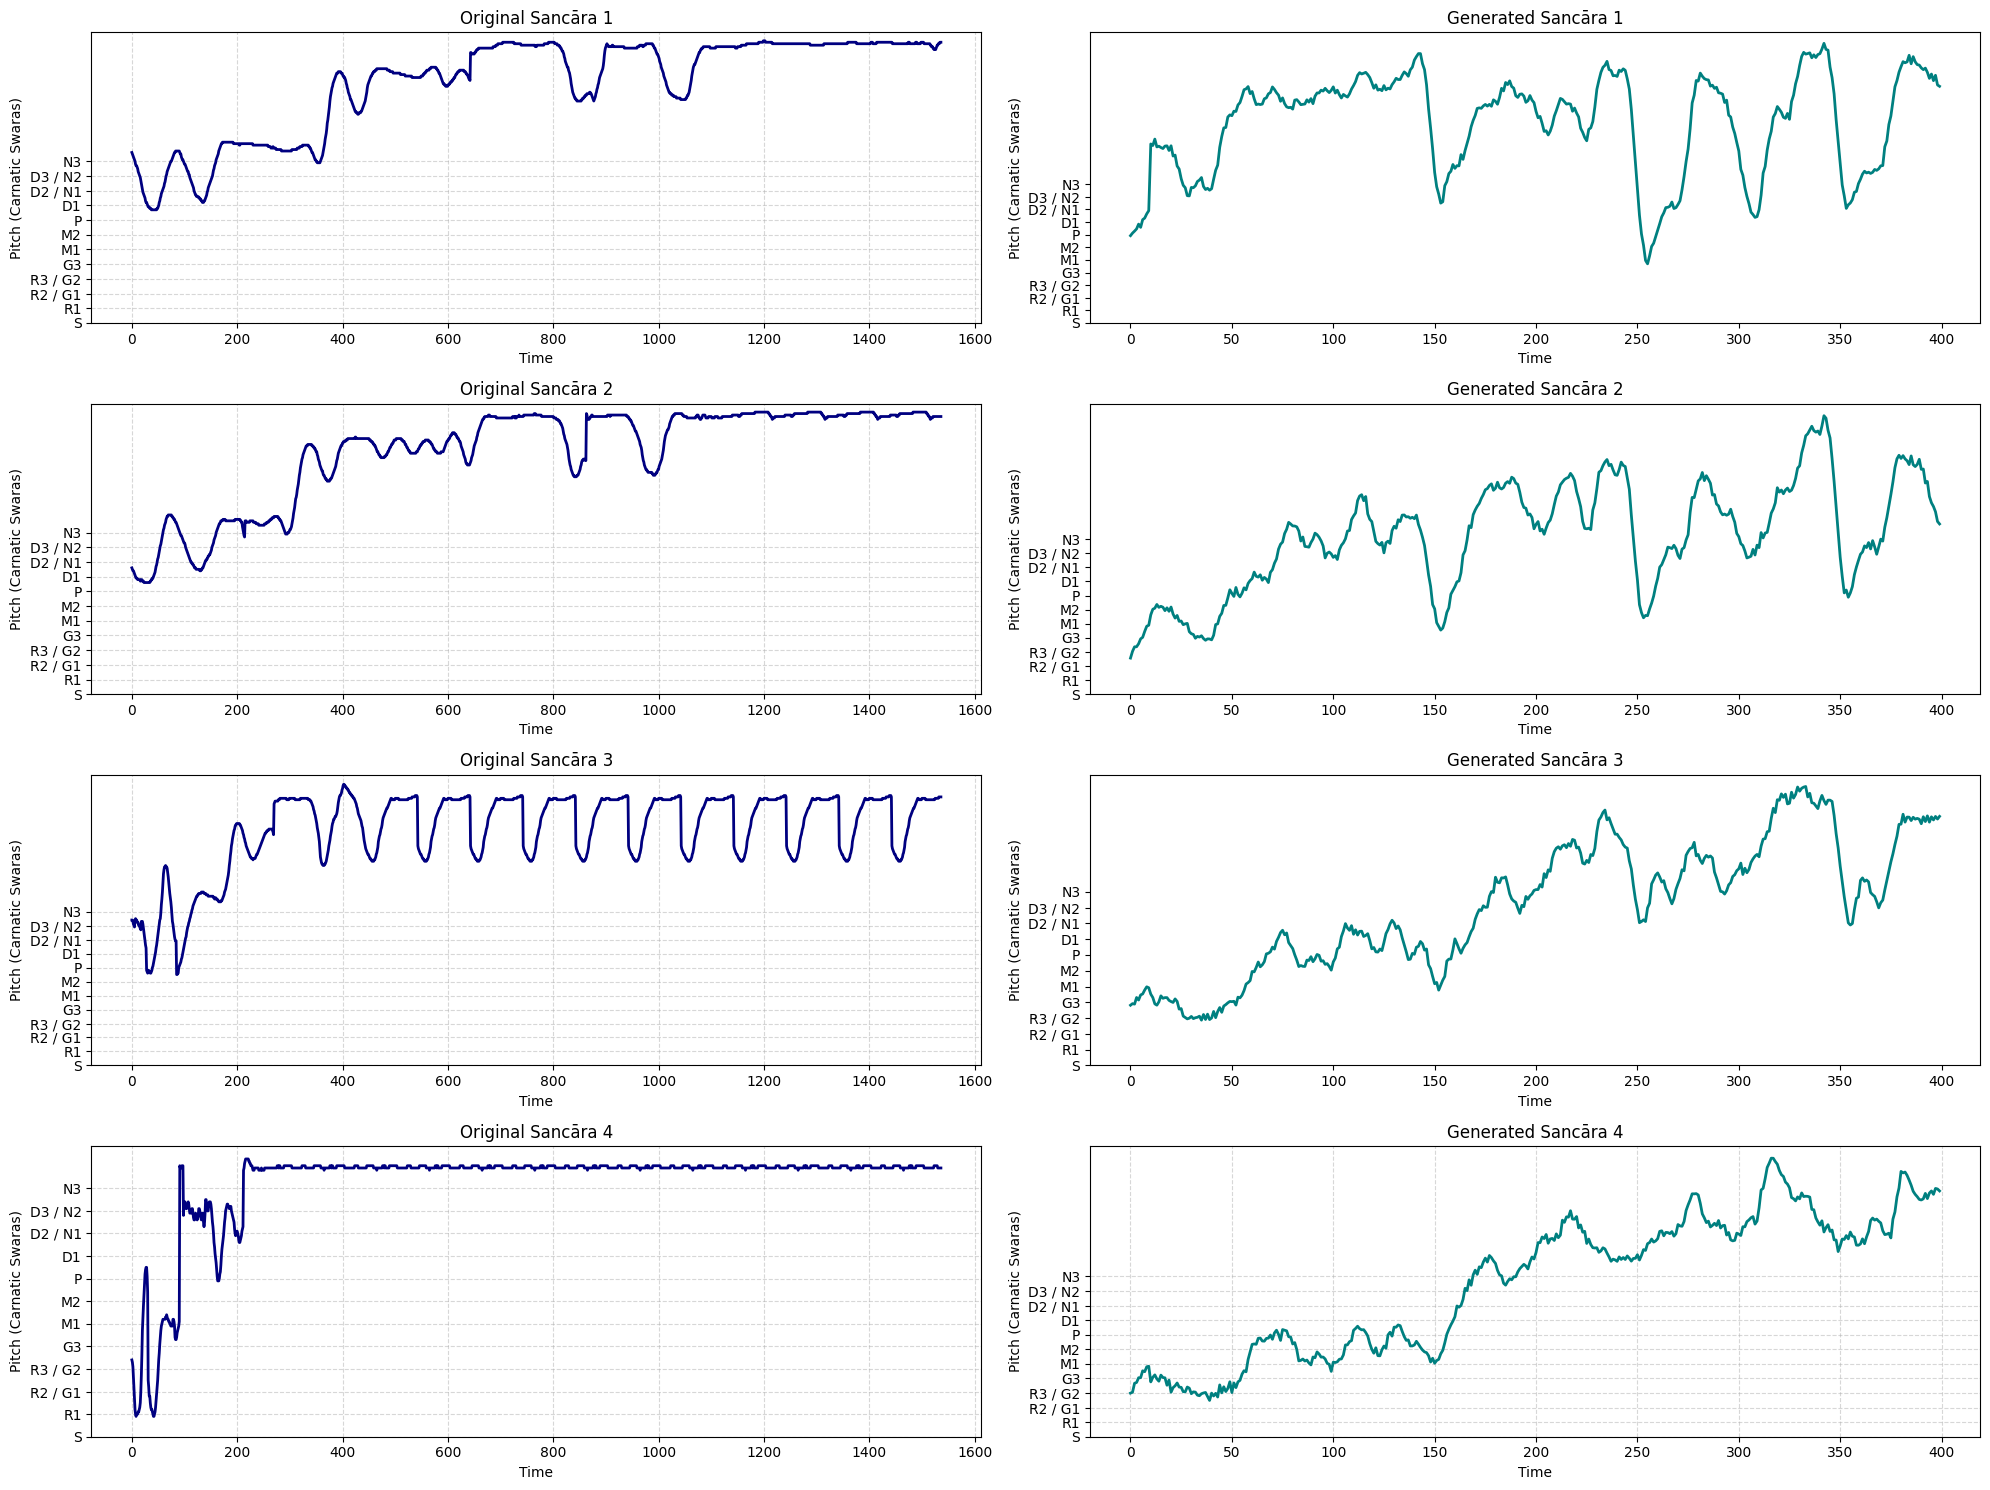

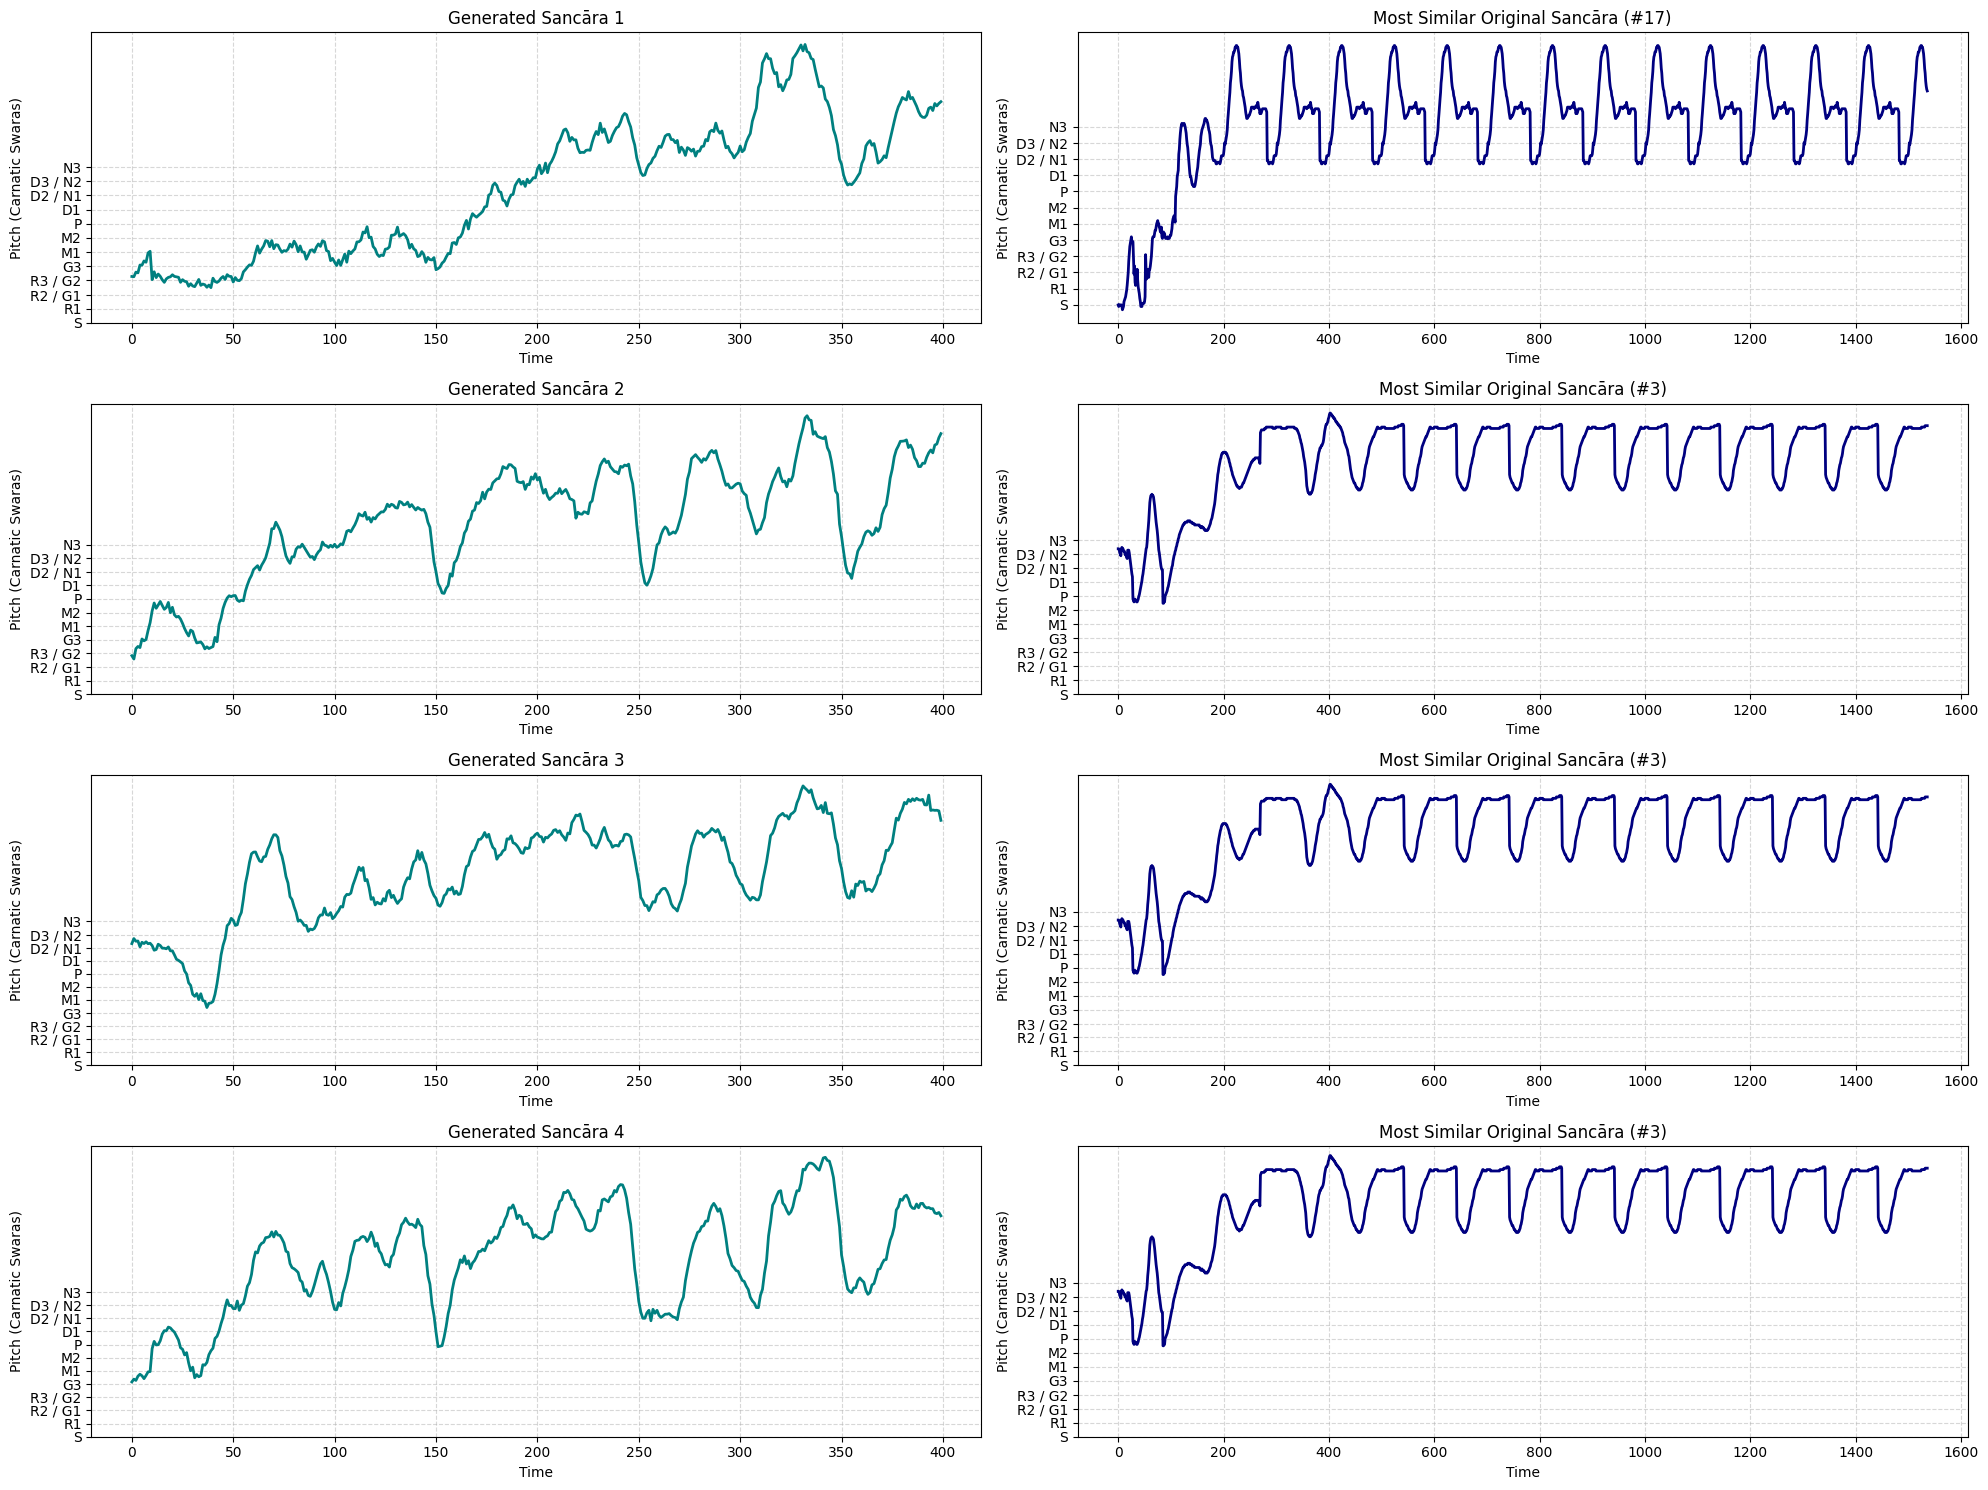

In [ ]:
import json
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from scipy.signal import savgol_filter

# ====================== Load and Normalize ======================
with open("/content/only_pitch_cents_grouped.json", "r") as file:
    raw_data = json.load(file)

def pad_with_last_100_pitches(sequences):
    max_len = max(len(seq) for seq in sequences)
    padded_sequences = []

    for seq in sequences:
        if len(seq) < max_len:
            last_100 = seq[-100:] if len(seq) >= 100 else seq  # If less than 100, take as much as possible
            repeats = (max_len - len(seq)) // len(last_100)
            remainder = (max_len - len(seq)) % len(last_100)

            padding = torch.cat([last_100] * repeats + [last_100[:remainder]])
            padded_seq = torch.cat([seq, padding])
        else:
            padded_seq = seq
        padded_sequences.append(padded_seq)

    return torch.stack(padded_sequences)

# Modified data loading and preprocessing
phrases = [torch.tensor([p for p in seq if p != 0], dtype=torch.float32) for seq in raw_data]
padded_phrases = pad_with_last_100_pitches(phrases)

# Calculate mean and std on non-padding values
mean = padded_phrases.mean()
std = padded_phrases.std()
padded_phrases = (padded_phrases - mean) / std

# ====================== Dataset ======================
class PhraseDataset(Dataset):
    def __init__(self, phrases):
        self.data = phrases

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = PhraseDataset(padded_phrases)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

# ====================== VAE Model ======================
class VAE(nn.Module):
    def __init__(self, seq_len, hidden_dim=1024, latent_dim=64):  # Increased dimensions
        super().__init__()

        # Encoder with musical context awareness
        self.encoder = nn.Sequential(
            nn.Linear(seq_len, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
        )

        self.mu = nn.Linear(hidden_dim // 2, latent_dim)
        self.logvar = nn.Linear(hidden_dim // 2, latent_dim)

        # Decoder with better pitch control
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, seq_len),
            nn.Tanh()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu  # During inference, just use the mean

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# ====================== Loss Function ======================
def vae_loss(recon_x, x, mu, logvar, beta=0.0005):  # Reduced beta for less KL impact
    # Reconstruction loss (MSE) with higher weight
    recon_loss = 2.0 * nn.MSELoss(reduction='mean')(recon_x, x)

    # KL divergence
    kl_div = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    # Pitch continuity loss with higher weight
    pitch_continuity = 0.2 * torch.mean((recon_x[:, 1:] - recon_x[:, :-1]).pow(2))

    # Pitch range consistency loss
    pitch_range = 0.1 * torch.mean((torch.max(recon_x, dim=1)[0] - torch.max(x, dim=1)[0]).pow(2) +
                            (torch.min(recon_x, dim=1)[0] - torch.min(x, dim=1)[0]).pow(2))

    return recon_loss + beta * kl_div + pitch_continuity + pitch_range

# ====================== Training ======================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seq_len = padded_phrases.shape[1]
model = VAE(seq_len=seq_len).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0003)  # Adjusted learning rate
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)

model.train()
for epoch in range(100):  # Increased epochs
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        recon, mu, logvar = model(batch)
        loss = vae_loss(recon, batch, mu, logvar)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Added gradient clipping
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss/len(loader)
    scheduler.step(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

# ====================== Helpers ======================
def smooth(seq, window=11, polyorder=3):
    if len(seq) < window:
        return seq
    return savgol_filter(seq, window_length=window, polyorder=polyorder)

def clip_pitch_range(seq, min_val=0, max_val=3000):
    return np.clip(seq, min_val, max_val)

def add_pitch_transition_rules(out):
    # Limit maximum pitch jump between consecutive notes
    max_jump = 200  # cents
    for i in range(1, len(out)):
        if abs(out[i] - out[i-1]) > max_jump:
            out[i] = out[i-1] + np.sign(out[i] - out[i-1]) * max_jump
    return out

def extract_raga_characteristics(all_pitches):
    # Calculate pitch distribution with more bins for better resolution
    pitch_hist, pitch_bins = np.histogram(all_pitches, bins=150)

    # Find primary and secondary prominent pitches
    primary_threshold = np.percentile(pitch_hist, 90)
    secondary_threshold = np.percentile(pitch_hist, 75)

    primary_pitches = pitch_bins[:-1][pitch_hist > primary_threshold]
    secondary_pitches = pitch_bins[:-1][(pitch_hist > secondary_threshold) & (pitch_hist <= primary_threshold)]

    return primary_pitches, secondary_pitches

def post_process_sancara(sancara, primary_pitches):
    # Ensure phrases start and end on important pitches
    start_pitch = primary_pitches[np.argmin(np.abs(sancara[0] - primary_pitches))]
    end_pitch = primary_pitches[np.argmin(np.abs(sancara[-1] - primary_pitches))]

    sancara[0:10] = np.linspace(sancara[0], start_pitch, 10)
    sancara[-10:] = np.linspace(sancara[-10], end_pitch, 10)

    return sancara

# ====================== Generate Variations ======================
def generate_new_raga_sancaras(model, dataset, num_samples=4, target_len=400):
    model.eval()
    generated = []

    # Analyze all input phrases
    all_phrases = []
    for i in range(len(dataset)):
        phrase = dataset[i].numpy() * std.item() + mean.item()
        all_phrases.append(phrase)

    all_pitches = np.concatenate(all_phrases)
    primary_pitches, secondary_pitches = extract_raga_characteristics(all_pitches)
    raga_min, raga_max = np.percentile(all_pitches, [1, 99])

    with torch.no_grad():
        for _ in range(num_samples):
            # Sample from a normal distribution with learned mean and variance
            z = torch.randn(1, model.mu.out_features).to(device) * 0.7  # Increased randomness

            # Add small random perturbations to z
            z += 0.1 * torch.randn_like(z)

            out = model.decode(z).squeeze(0)
            out = out[:target_len]
            out = out.cpu().numpy() * std.item() + mean.item()

            # Scale to raga pitch range
            out = ((out - np.min(out)) / (np.max(out) - np.min(out)) *
                  (raga_max - raga_min) + raga_min)

            # Apply enhanced musical constraints
            out = smooth(out, window=15, polyorder=2)

            # Strong attraction to primary pitches
            for pitch in primary_pitches:
                mask = np.abs(out - pitch) < 25  # Increased attraction range
                out[mask] = 0.95 * out[mask] + 0.05 * pitch

            # Weaker attraction to secondary pitches
            for pitch in secondary_pitches:
                mask = np.abs(out - pitch) < 30
                out[mask] = 0.7 * out[mask] + 0.3 * pitch

            # Apply pitch transition rules
            out = add_pitch_transition_rules(out)

            # Final smoothing and boundary enforcement
            out = smooth(out, window=11, polyorder=2)
            out = clip_pitch_range(out, min_val=raga_min, max_val=raga_max)

            # Post-process the generated sancara
            out = post_process_sancara(out, primary_pitches)

            # Add small random variations while maintaining overall shape
            noise = np.random.normal(0, 20, out.shape)  # Small random fluctuations
            out += noise

            generated.append(out)

    return generated

# Generate and visualize new raga-based sancāras
new_sancaras = generate_new_raga_sancaras(model, dataset, num_samples=4)

# Plot the generated sancāras in a grid
import numpy as np
import matplotlib.pyplot as plt

# Function to map pitch values (in cents) to Carnatic music note names
def pitch_to_carnatic_note_name(pitch):
    """Convert pitch value in cents to Carnatic music note name."""
    # Note names based on standard Carnatic music notation
    cent_intervals = np.arange(0, 1200, 100)
    swaras = ['S', 'R1', 'R2 / G1', 'R3 / G2', 'G3', 'M1', 'M2', 'P', 'D1', 'D2 / N1', 'D3 / N2', 'N3']
    idx = int(round(pitch / 100))
    if 0 <= idx < len(swaras):
        return swaras[idx]
    return ''

# Generate and visualize new raga-based sancāras
new_sancaras = generate_new_raga_sancaras(model, dataset, num_samples=4)

# Plot the generated sancāras in a grid
plt.figure(figsize=(15, 10))
for i, sancara in enumerate(new_sancaras):
    plt.subplot(2, 2, i+1)
    plt.plot(sancara, linewidth=2, color='teal')
    plt.title(f"Generated Sancāra {i+1}", fontsize=12)
    plt.xlabel("Time")
    plt.ylabel("Pitch (Carnatic Swaras)")

    # Set Y-ticks every 100 cents with Carnatic swara labels
    y_ticks = np.arange(0, 1200, 100)
    y_labels = ['S', 'R1', 'R2 / G1', 'R3 / G2', 'G3', 'M1', 'M2', 'P', 'D1', 'D2 / N1', 'D3 / N2', 'N3']
    plt.yticks(y_ticks, y_labels)

    plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# After the generate_new_raga_sancaras function, add:

def plot_comparison(original_dataset, generated_sancaras, num_samples=4):
    """Plot original and generated sancāras side by side"""
    plt.figure(figsize=(20, 15))

    # Plot original sancāras
    for i in range(num_samples):
        plt.subplot(num_samples, 2, 2*i + 1)
        original = original_dataset[i].numpy() * std.item() + mean.item()
        plt.plot(original, linewidth=2, color='navy')
        plt.title(f"Original Sancāra {i+1}", fontsize=12)
        plt.xlabel("Time")
        plt.ylabel("Pitch (Carnatic Swaras)")
        # Set Y-ticks every 100 cents with Carnatic swara labels
        y_ticks = np.arange(0, 1200, 100)
        y_labels = ['S', 'R1', 'R2 / G1', 'R3 / G2', 'G3', 'M1', 'M2', 'P', 'D1', 'D2 / N1', 'D3 / N2', 'N3']
        plt.yticks(y_ticks, y_labels)

        plt.grid(True, linestyle='--', alpha=0.5)
        # Plot generated sancāras
        plt.subplot(num_samples, 2, 2*i + 2)
        plt.plot(generated_sancaras[i], linewidth=2, color='teal')
        plt.title(f"Generated Sancāra {i+1}", fontsize=12)
        plt.xlabel("Time")
        plt.ylabel("Pitch (Carnatic Swaras)")
        # Set Y-ticks every 100 cents with Carnatic swara labels
        y_ticks = np.arange(0, 1200, 100)
        y_labels = ['S', 'R1', 'R2 / G1', 'R3 / G2', 'G3', 'M1', 'M2', 'P', 'D1', 'D2 / N1', 'D3 / N2', 'N3']
        plt.yticks(y_ticks, y_labels)

    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# Generate and visualize the comparison
new_sancaras = generate_new_raga_sancaras(model, dataset, num_samples=4)
plot_comparison(dataset, new_sancaras)

def find_most_similar_pair(original_dataset, generated_sancara):
    """Find the most similar original sancara to a generated one using MSE"""
    min_mse = float('inf')
    best_idx = 0

    gen_sancara = generated_sancara[:400]  # Use first 400 points for comparison

    for i in range(len(original_dataset)):
        orig = original_dataset[i].numpy() * std.item() + mean.item()
        orig = orig[:400]  # Use first 400 points

        # Calculate MSE between the sequences
        mse = np.mean((orig - gen_sancara)**2)

        if mse < min_mse:
            min_mse = mse
            best_idx = i

    return best_idx

def plot_similar_pairs(original_dataset, generated_sancaras, num_samples=4):
    """Plot most similar original and generated sancāras side by side"""
    plt.figure(figsize=(20, 15))

    for i in range(num_samples):
        # Find most similar original sancara
        best_idx = find_most_similar_pair(original_dataset, generated_sancaras[i])

        # Plot generated sancara on the left
        plt.subplot(num_samples, 2, 2*i + 1)
        plt.plot(generated_sancaras[i], linewidth=2, color='teal')
        plt.title(f"Generated Sancāra {i+1}", fontsize=12)
        plt.xlabel("Time")
        plt.ylabel("Pitch (Carnatic Swaras)")
        # Set Y-ticks every 100 cents with Carnatic swara labels
        y_ticks = np.arange(0, 1200, 100)
        y_labels = ['S', 'R1', 'R2 / G1', 'R3 / G2', 'G3', 'M1', 'M2', 'P', 'D1', 'D2 / N1', 'D3 / N2', 'N3']
        plt.yticks(y_ticks, y_labels)

        plt.grid(True, linestyle='--', alpha=0.5)

        # Plot matching original sancara on the right
        plt.subplot(num_samples, 2, 2*i + 2)
        original = original_dataset[best_idx].numpy() * std.item() + mean.item()
        plt.plot(original, linewidth=2, color='navy')
        plt.title(f"Most Similar Original Sancāra (#{best_idx+1})", fontsize=12)
        plt.xlabel("Time")
        plt.ylabel("Pitch (Carnatic Swaras)")
        # Set Y-ticks every 100 cents with Carnatic swara labels
        y_ticks = np.arange(0, 1200, 100)
        y_labels = ['S', 'R1', 'R2 / G1', 'R3 / G2', 'G3', 'M1', 'M2', 'P', 'D1', 'D2 / N1', 'D3 / N2', 'N3']
        plt.yticks(y_ticks, y_labels)

        plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# Generate and visualize similar pairs
new_sancaras = generate_new_raga_sancaras(model, dataset, num_samples=4)
plot_similar_pairs(dataset, new_sancaras)

Epoch 1, Loss: 3.6270
Epoch 2, Loss: 3.5531
Epoch 3, Loss: 3.3597
Epoch 4, Loss: 3.4205
Epoch 5, Loss: 3.3433
Epoch 6, Loss: 3.2670
Epoch 7, Loss: 3.1162
Epoch 8, Loss: 3.2958
Epoch 9, Loss: 3.1011
Epoch 10, Loss: 2.9370
Epoch 11, Loss: 2.8610
Epoch 12, Loss: 2.8664
Epoch 13, Loss: 2.7554
Epoch 14, Loss: 2.8476
Epoch 15, Loss: 2.8246
Epoch 16, Loss: 2.6937
Epoch 17, Loss: 2.5476
Epoch 18, Loss: 2.6135
Epoch 19, Loss: 2.4982
Epoch 20, Loss: 2.5475
Epoch 21, Loss: 2.4812
Epoch 22, Loss: 2.4906
Epoch 23, Loss: 2.4769
Epoch 24, Loss: 2.4763
Epoch 25, Loss: 2.5227
Epoch 26, Loss: 2.6459
Epoch 27, Loss: 2.6509
Epoch 28, Loss: 2.4079
Epoch 29, Loss: 2.3448
Epoch 30, Loss: 2.3614
Epoch 31, Loss: 2.4838
Epoch 32, Loss: 2.4723
Epoch 33, Loss: 2.4191
Epoch 34, Loss: 2.3490
Epoch 35, Loss: 2.3409
Epoch 36, Loss: 2.1989
Epoch 37, Loss: 2.2648
Epoch 38, Loss: 2.3887
Epoch 39, Loss: 2.3061
Epoch 40, Loss: 2.2036
Epoch 41, Loss: 2.2820
Epoch 42, Loss: 2.2407
Epoch 43, Loss: 2.3184
Epoch 44, Loss: 2.27

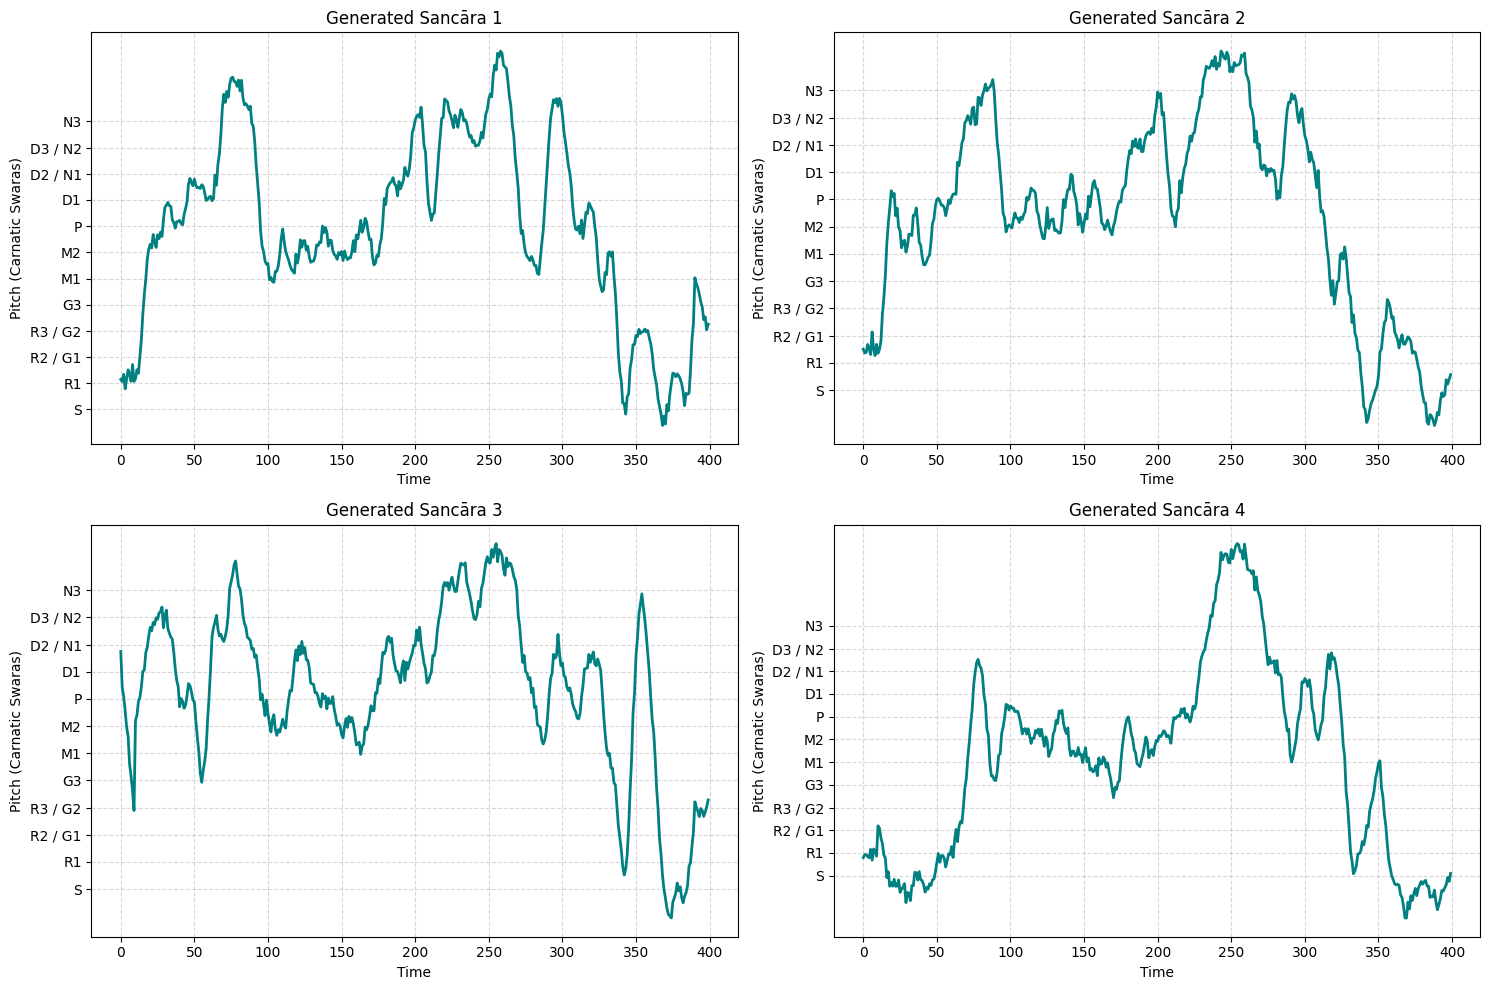

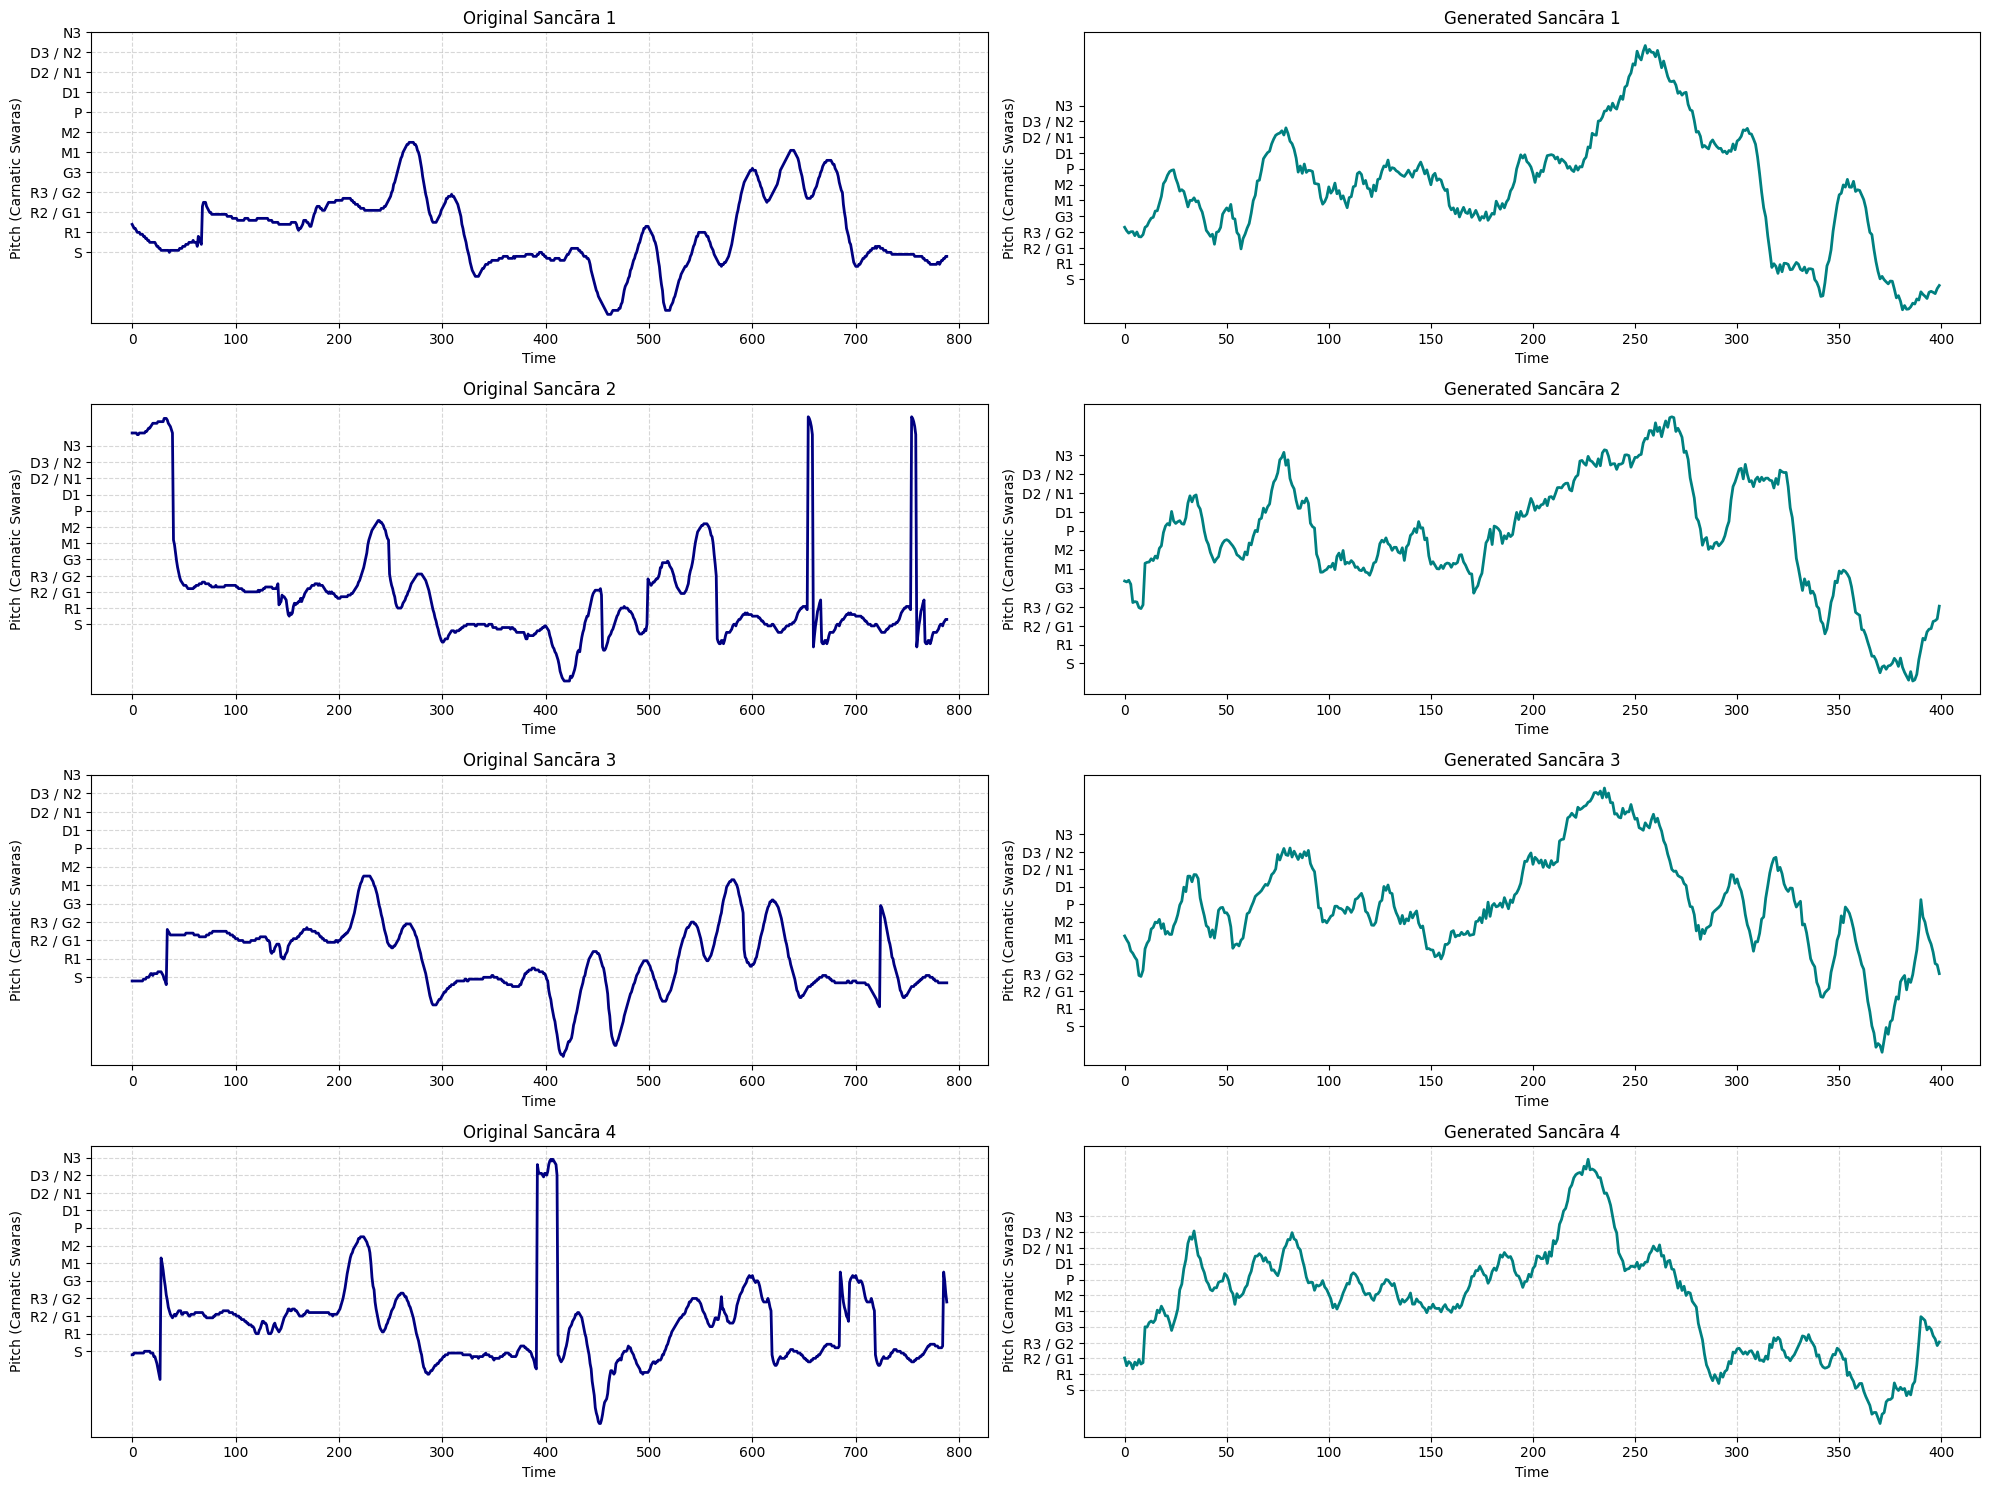

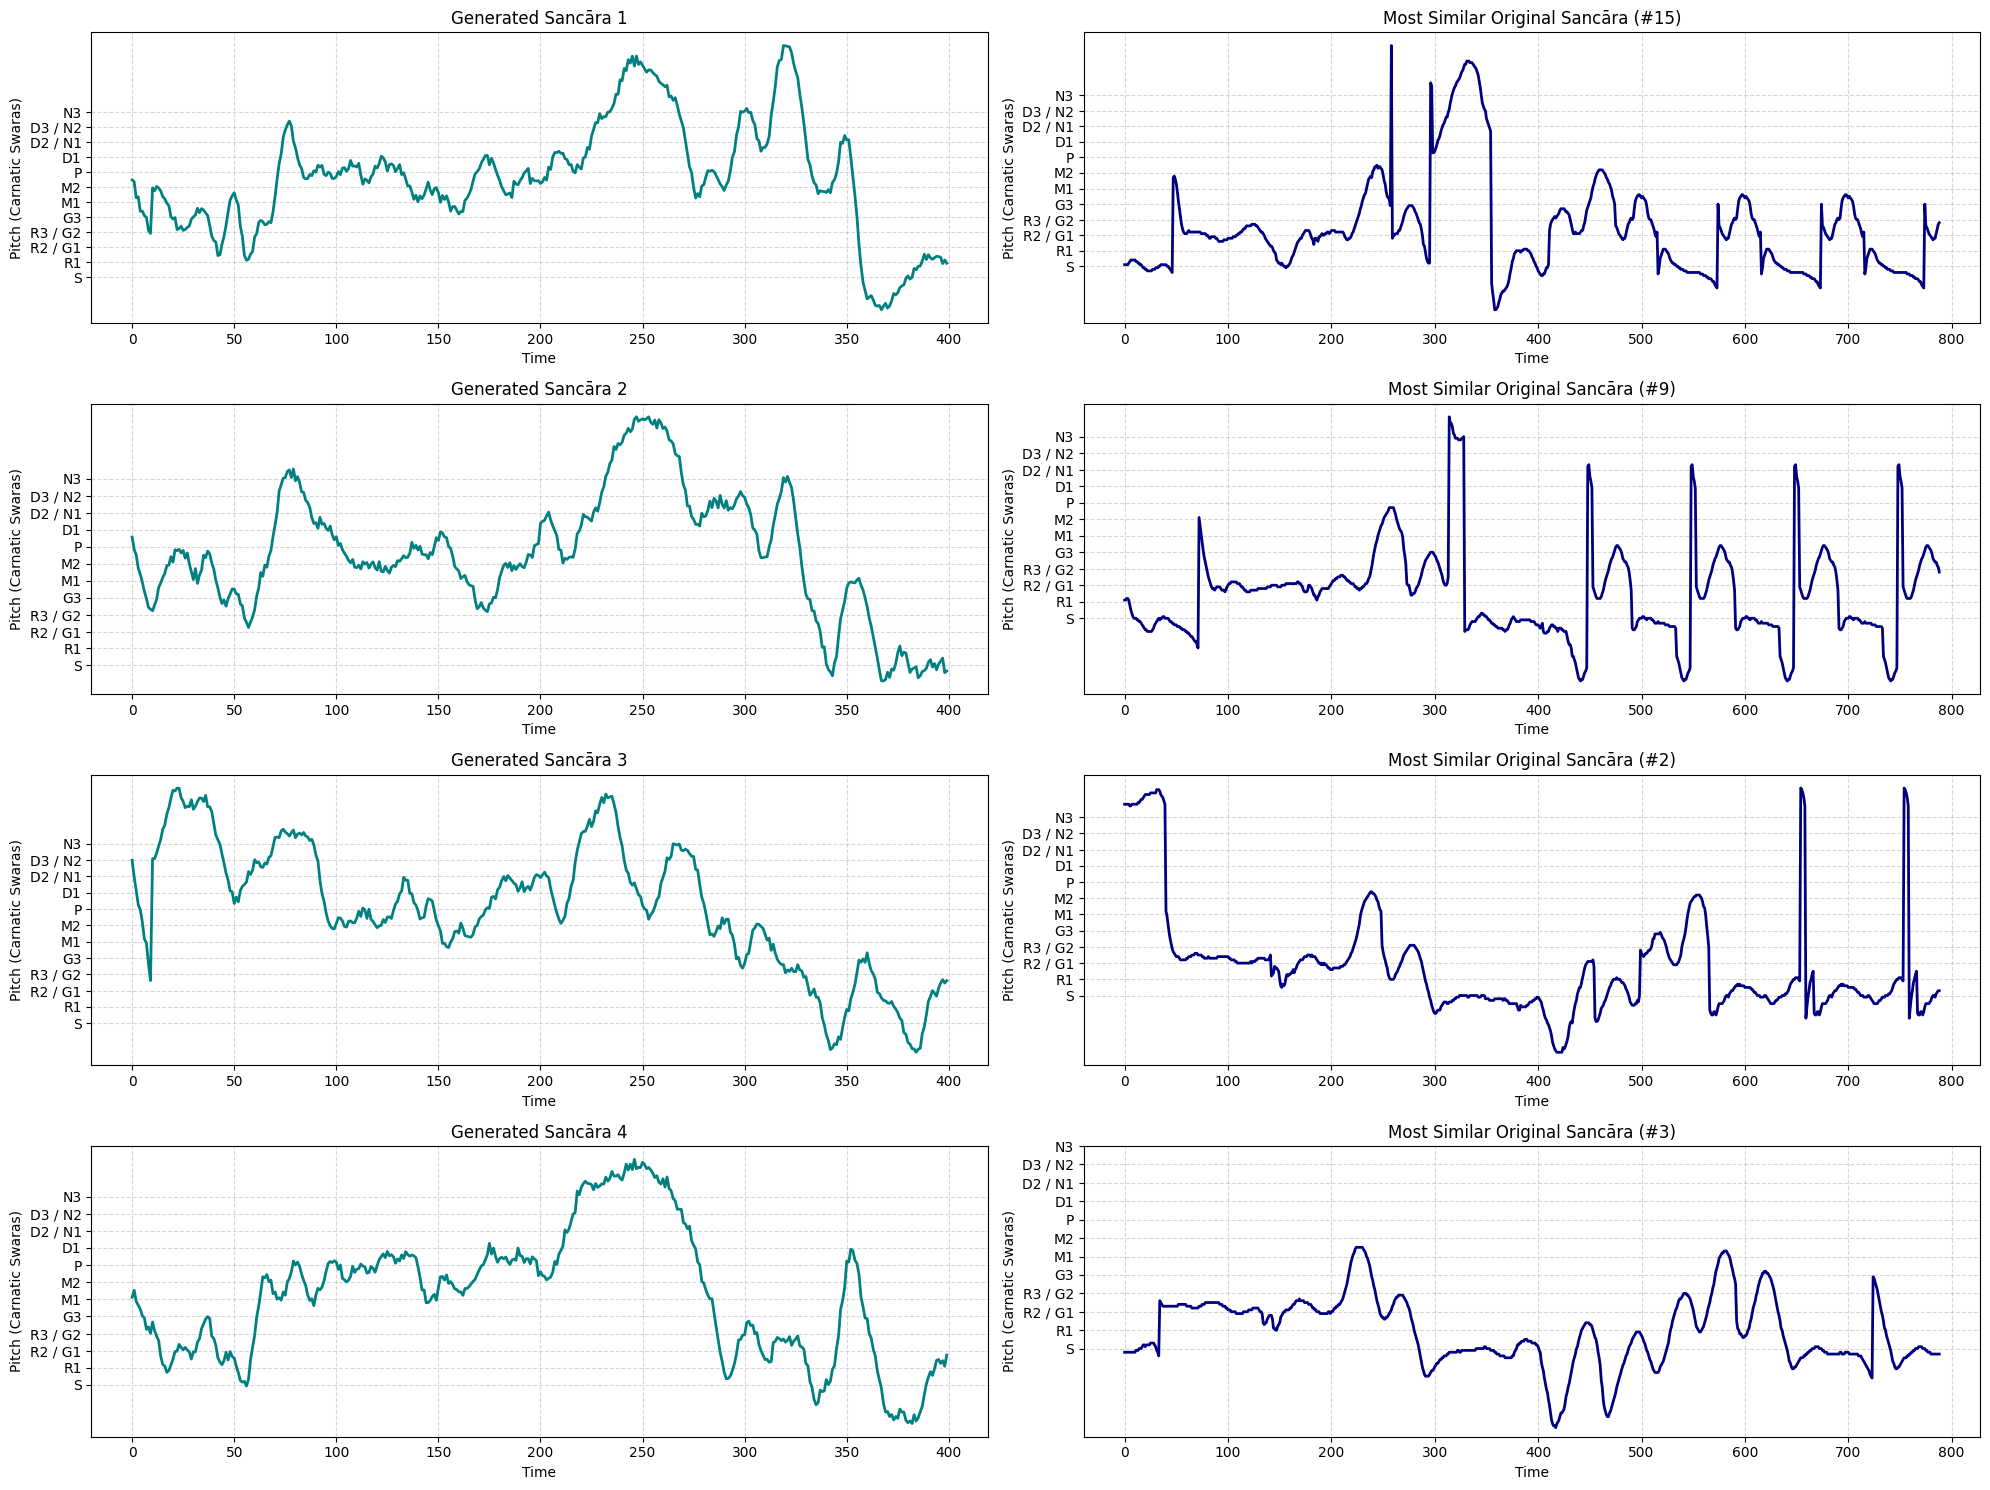

In [ ]:
import json
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from scipy.signal import savgol_filter

# ====================== Load and Normalize ======================
with open("/content/only_pitch_cents_grouped1.json", "r") as file:
    raw_data = json.load(file)

def pad_with_last_100_pitches(sequences):
    max_len = max(len(seq) for seq in sequences)
    padded_sequences = []

    for seq in sequences:
        if len(seq) < max_len:
            last_100 = seq[-100:] if len(seq) >= 100 else seq  # If less than 100, take as much as possible
            repeats = (max_len - len(seq)) // len(last_100)
            remainder = (max_len - len(seq)) % len(last_100)

            padding = torch.cat([last_100] * repeats + [last_100[:remainder]])
            padded_seq = torch.cat([seq, padding])
        else:
            padded_seq = seq
        padded_sequences.append(padded_seq)

    return torch.stack(padded_sequences)

# Modified data loading and preprocessing
phrases = [torch.tensor([p for p in seq if p != 0], dtype=torch.float32) for seq in raw_data]
padded_phrases = pad_with_last_100_pitches(phrases)

# Calculate mean and std on non-padding values
mean = padded_phrases.mean()
std = padded_phrases.std()
padded_phrases = (padded_phrases - mean) / std

# ====================== Dataset ======================
class PhraseDataset(Dataset):
    def __init__(self, phrases):
        self.data = phrases

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = PhraseDataset(padded_phrases)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

# ====================== VAE Model ======================
class VAE(nn.Module):
    def __init__(self, seq_len, hidden_dim=1024, latent_dim=64):  # Increased dimensions
        super().__init__()

        # Encoder with musical context awareness
        self.encoder = nn.Sequential(
            nn.Linear(seq_len, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
        )

        self.mu = nn.Linear(hidden_dim // 2, latent_dim)
        self.logvar = nn.Linear(hidden_dim // 2, latent_dim)

        # Decoder with better pitch control
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, seq_len),
            nn.Tanh()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu  # During inference, just use the mean

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# ====================== Loss Function ======================
def vae_loss(recon_x, x, mu, logvar, beta=0.0005):  # Reduced beta for less KL impact
    # Reconstruction loss (MSE) with higher weight
    recon_loss = 2.0 * nn.MSELoss(reduction='mean')(recon_x, x)

    # KL divergence
    kl_div = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    # Pitch continuity loss with higher weight
    pitch_continuity = 0.2 * torch.mean((recon_x[:, 1:] - recon_x[:, :-1]).pow(2))

    # Pitch range consistency loss
    pitch_range = 0.1 * torch.mean((torch.max(recon_x, dim=1)[0] - torch.max(x, dim=1)[0]).pow(2) +
                            (torch.min(recon_x, dim=1)[0] - torch.min(x, dim=1)[0]).pow(2))

    return recon_loss + beta * kl_div + pitch_continuity + pitch_range

# ====================== Training ======================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seq_len = padded_phrases.shape[1]
model = VAE(seq_len=seq_len).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0003)  # Adjusted learning rate
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)

model.train()
for epoch in range(100):  # Increased epochs
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        recon, mu, logvar = model(batch)
        loss = vae_loss(recon, batch, mu, logvar)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Added gradient clipping
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss/len(loader)
    scheduler.step(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

# ====================== Helpers ======================
def smooth(seq, window=11, polyorder=3):
    if len(seq) < window:
        return seq
    return savgol_filter(seq, window_length=window, polyorder=polyorder)

def clip_pitch_range(seq, min_val=0, max_val=3000):
    return np.clip(seq, min_val, max_val)

def add_pitch_transition_rules(out):
    # Limit maximum pitch jump between consecutive notes
    max_jump = 200  # cents
    for i in range(1, len(out)):
        if abs(out[i] - out[i-1]) > max_jump:
            out[i] = out[i-1] + np.sign(out[i] - out[i-1]) * max_jump
    return out

def extract_raga_characteristics(all_pitches):
    # Calculate pitch distribution with more bins for better resolution
    pitch_hist, pitch_bins = np.histogram(all_pitches, bins=150)

    # Find primary and secondary prominent pitches
    primary_threshold = np.percentile(pitch_hist, 90)
    secondary_threshold = np.percentile(pitch_hist, 75)

    primary_pitches = pitch_bins[:-1][pitch_hist > primary_threshold]
    secondary_pitches = pitch_bins[:-1][(pitch_hist > secondary_threshold) & (pitch_hist <= primary_threshold)]

    return primary_pitches, secondary_pitches

def post_process_sancara(sancara, primary_pitches):
    # Ensure phrases start and end on important pitches
    start_pitch = primary_pitches[np.argmin(np.abs(sancara[0] - primary_pitches))]
    end_pitch = primary_pitches[np.argmin(np.abs(sancara[-1] - primary_pitches))]

    sancara[0:10] = np.linspace(sancara[0], start_pitch, 10)
    sancara[-10:] = np.linspace(sancara[-10], end_pitch, 10)

    return sancara

# ====================== Generate Variations ======================
def generate_new_raga_sancaras(model, dataset, num_samples=4, target_len=400):
    model.eval()
    generated = []

    # Analyze all input phrases
    all_phrases = []
    for i in range(len(dataset)):
        phrase = dataset[i].numpy() * std.item() + mean.item()
        all_phrases.append(phrase)

    all_pitches = np.concatenate(all_phrases)
    primary_pitches, secondary_pitches = extract_raga_characteristics(all_pitches)
    raga_min, raga_max = np.percentile(all_pitches, [1, 99])

    with torch.no_grad():
        for _ in range(num_samples):
            # Sample from a normal distribution with learned mean and variance
            z = torch.randn(1, model.mu.out_features).to(device) * 0.7  # Increased randomness

            # Add small random perturbations to z
            z += 0.1 * torch.randn_like(z)

            out = model.decode(z).squeeze(0)
            out = out[:target_len]
            out = out.cpu().numpy() * std.item() + mean.item()

            # Scale to raga pitch range
            out = ((out - np.min(out)) / (np.max(out) - np.min(out)) *
                  (raga_max - raga_min) + raga_min)

            # Apply enhanced musical constraints
            out = smooth(out, window=15, polyorder=2)

            # Strong attraction to primary pitches
            for pitch in primary_pitches:
                mask = np.abs(out - pitch) < 25  # Increased attraction range
                out[mask] = 0.95 * out[mask] + 0.05 * pitch

            # Weaker attraction to secondary pitches
            for pitch in secondary_pitches:
                mask = np.abs(out - pitch) < 30
                out[mask] = 0.7 * out[mask] + 0.3 * pitch

            # Apply pitch transition rules
            out = add_pitch_transition_rules(out)

            # Final smoothing and boundary enforcement
            out = smooth(out, window=11, polyorder=2)
            out = clip_pitch_range(out, min_val=raga_min, max_val=raga_max)

            # Post-process the generated sancara
            out = post_process_sancara(out, primary_pitches)

            # Add small random variations while maintaining overall shape
            noise = np.random.normal(0, 20, out.shape)  # Small random fluctuations
            out += noise

            generated.append(out)

    return generated

# Generate and visualize new raga-based sancāras
new_sancaras = generate_new_raga_sancaras(model, dataset, num_samples=4)

# Plot the generated sancāras in a grid
import numpy as np
import matplotlib.pyplot as plt

# Function to map pitch values (in cents) to Carnatic music note names
def pitch_to_carnatic_note_name(pitch):
    """Convert pitch value in cents to Carnatic music note name."""
    # Note names based on standard Carnatic music notation
    cent_intervals = np.arange(0, 1200, 100)
    swaras = ['S', 'R1', 'R2 / G1', 'R3 / G2', 'G3', 'M1', 'M2', 'P', 'D1', 'D2 / N1', 'D3 / N2', 'N3']
    idx = int(round(pitch / 100))
    if 0 <= idx < len(swaras):
        return swaras[idx]
    return ''

# Generate and visualize new raga-based sancāras
new_sancaras = generate_new_raga_sancaras(model, dataset, num_samples=4)

# Plot the generated sancāras in a grid
plt.figure(figsize=(15, 10))
for i, sancara in enumerate(new_sancaras):
    plt.subplot(2, 2, i+1)
    plt.plot(sancara, linewidth=2, color='teal')
    plt.title(f"Generated Sancāra {i+1}", fontsize=12)
    plt.xlabel("Time")
    plt.ylabel("Pitch (Carnatic Swaras)")

    # Set Y-ticks every 100 cents with Carnatic swara labels
    y_ticks = np.arange(0, 1200, 100)
    y_labels = ['S', 'R1', 'R2 / G1', 'R3 / G2', 'G3', 'M1', 'M2', 'P', 'D1', 'D2 / N1', 'D3 / N2', 'N3']
    plt.yticks(y_ticks, y_labels)

    plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# After the generate_new_raga_sancaras function, add:

def plot_comparison(original_dataset, generated_sancaras, num_samples=4):
    """Plot original and generated sancāras side by side"""
    plt.figure(figsize=(20, 15))

    # Plot original sancāras
    for i in range(num_samples):
        plt.subplot(num_samples, 2, 2*i + 1)
        original = original_dataset[i].numpy() * std.item() + mean.item()
        plt.plot(original, linewidth=2, color='navy')
        plt.title(f"Original Sancāra {i+1}", fontsize=12)
        plt.xlabel("Time")
        plt.ylabel("Pitch (Carnatic Swaras)")
        # Set Y-ticks every 100 cents with Carnatic swara labels
        y_ticks = np.arange(0, 1200, 100)
        y_labels = ['S', 'R1', 'R2 / G1', 'R3 / G2', 'G3', 'M1', 'M2', 'P', 'D1', 'D2 / N1', 'D3 / N2', 'N3']
        plt.yticks(y_ticks, y_labels)

        plt.grid(True, linestyle='--', alpha=0.5)
        # Plot generated sancāras
        plt.subplot(num_samples, 2, 2*i + 2)
        plt.plot(generated_sancaras[i], linewidth=2, color='teal')
        plt.title(f"Generated Sancāra {i+1}", fontsize=12)
        plt.xlabel("Time")
        plt.ylabel("Pitch (Carnatic Swaras)")
        # Set Y-ticks every 100 cents with Carnatic swara labels
        y_ticks = np.arange(0, 1200, 100)
        y_labels = ['S', 'R1', 'R2 / G1', 'R3 / G2', 'G3', 'M1', 'M2', 'P', 'D1', 'D2 / N1', 'D3 / N2', 'N3']
        plt.yticks(y_ticks, y_labels)

    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# Generate and visualize the comparison
new_sancaras = generate_new_raga_sancaras(model, dataset, num_samples=4)
plot_comparison(dataset, new_sancaras)

def find_most_similar_pair(original_dataset, generated_sancara):
    """Find the most similar original sancara to a generated one using MSE"""
    min_mse = float('inf')
    best_idx = 0

    gen_sancara = generated_sancara[:400]  # Use first 400 points for comparison

    for i in range(len(original_dataset)):
        orig = original_dataset[i].numpy() * std.item() + mean.item()
        orig = orig[:400]  # Use first 400 points

        # Calculate MSE between the sequences
        mse = np.mean((orig - gen_sancara)**2)

        if mse < min_mse:
            min_mse = mse
            best_idx = i

    return best_idx

def plot_similar_pairs(original_dataset, generated_sancaras, num_samples=4):
    """Plot most similar original and generated sancāras side by side"""
    plt.figure(figsize=(20, 15))

    for i in range(num_samples):
        # Find most similar original sancara
        best_idx = find_most_similar_pair(original_dataset, generated_sancaras[i])

        # Plot generated sancara on the left
        plt.subplot(num_samples, 2, 2*i + 1)
        plt.plot(generated_sancaras[i], linewidth=2, color='teal')
        plt.title(f"Generated Sancāra {i+1}", fontsize=12)
        plt.xlabel("Time")
        plt.ylabel("Pitch (Carnatic Swaras)")
        # Set Y-ticks every 100 cents with Carnatic swara labels
        y_ticks = np.arange(0, 1200, 100)
        y_labels = ['S', 'R1', 'R2 / G1', 'R3 / G2', 'G3', 'M1', 'M2', 'P', 'D1', 'D2 / N1', 'D3 / N2', 'N3']
        plt.yticks(y_ticks, y_labels)

        plt.grid(True, linestyle='--', alpha=0.5)

        # Plot matching original sancara on the right
        plt.subplot(num_samples, 2, 2*i + 2)
        original = original_dataset[best_idx].numpy() * std.item() + mean.item()
        plt.plot(original, linewidth=2, color='navy')
        plt.title(f"Most Similar Original Sancāra (#{best_idx+1})", fontsize=12)
        plt.xlabel("Time")
        plt.ylabel("Pitch (Carnatic Swaras)")
        # Set Y-ticks every 100 cents with Carnatic swara labels
        y_ticks = np.arange(0, 1200, 100)
        y_labels = ['S', 'R1', 'R2 / G1', 'R3 / G2', 'G3', 'M1', 'M2', 'P', 'D1', 'D2 / N1', 'D3 / N2', 'N3']
        plt.yticks(y_ticks, y_labels)
        plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# Generate and visualize similar pairs
new_sancaras = generate_new_raga_sancaras(model, dataset, num_samples=4)
plot_similar_pairs(dataset, new_sancaras)

Epoch 1, Loss: 1.0634
Epoch 2, Loss: 1.0620
Epoch 3, Loss: 1.0386
Epoch 4, Loss: 1.0111
Epoch 5, Loss: 0.9957
Epoch 6, Loss: 0.9647
Epoch 7, Loss: 0.9291
Epoch 8, Loss: 0.8825
Epoch 9, Loss: 0.8384
Epoch 10, Loss: 0.7885
Epoch 11, Loss: 0.7409
Epoch 12, Loss: 0.6936
Epoch 13, Loss: 0.6469
Epoch 14, Loss: 0.6009
Epoch 15, Loss: 0.5627
Epoch 16, Loss: 0.5262
Epoch 17, Loss: 0.4928
Epoch 18, Loss: 0.4681
Epoch 19, Loss: 0.4449
Epoch 20, Loss: 0.4270
Epoch 21, Loss: 0.4107
Epoch 22, Loss: 0.3961
Epoch 23, Loss: 0.3843
Epoch 24, Loss: 0.3724
Epoch 25, Loss: 0.3625
Epoch 26, Loss: 0.3529
Epoch 27, Loss: 0.3439
Epoch 28, Loss: 0.3321
Epoch 29, Loss: 0.3229
Epoch 30, Loss: 0.3123
Epoch 31, Loss: 0.3024
Epoch 32, Loss: 0.2922
Epoch 33, Loss: 0.2826
Epoch 34, Loss: 0.2729
Epoch 35, Loss: 0.2637
Epoch 36, Loss: 0.2542
Epoch 37, Loss: 0.2459
Epoch 38, Loss: 0.2386
Epoch 39, Loss: 0.2303
Epoch 40, Loss: 0.2232
Epoch 41, Loss: 0.2161
Epoch 42, Loss: 0.2098
Epoch 43, Loss: 0.2028
Epoch 44, Loss: 0.19

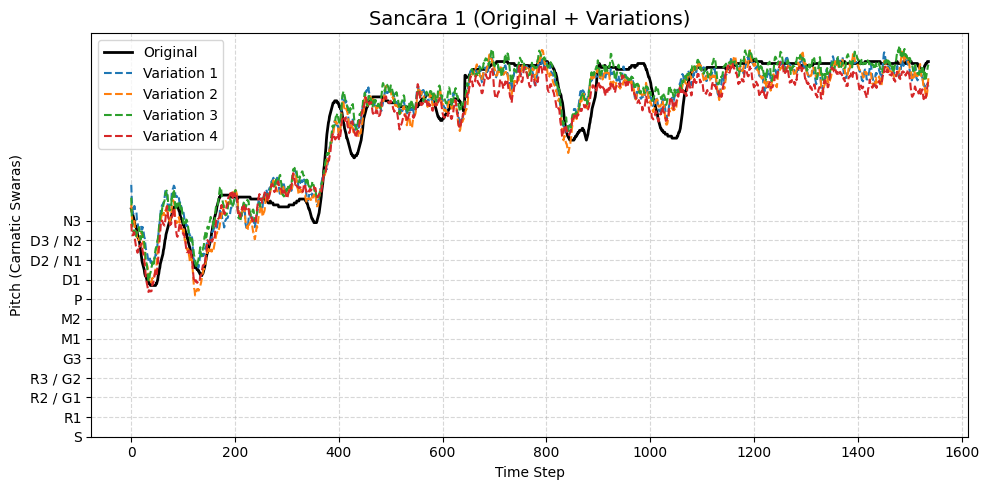

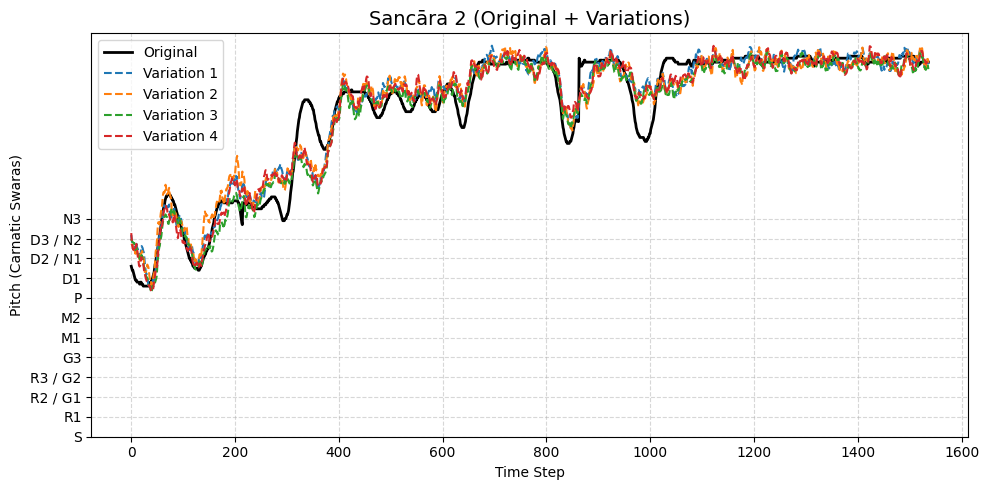

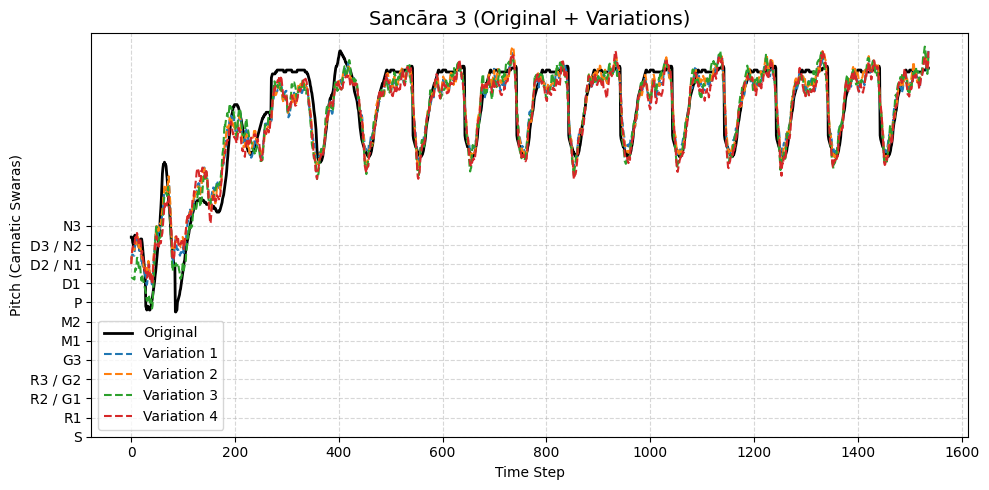

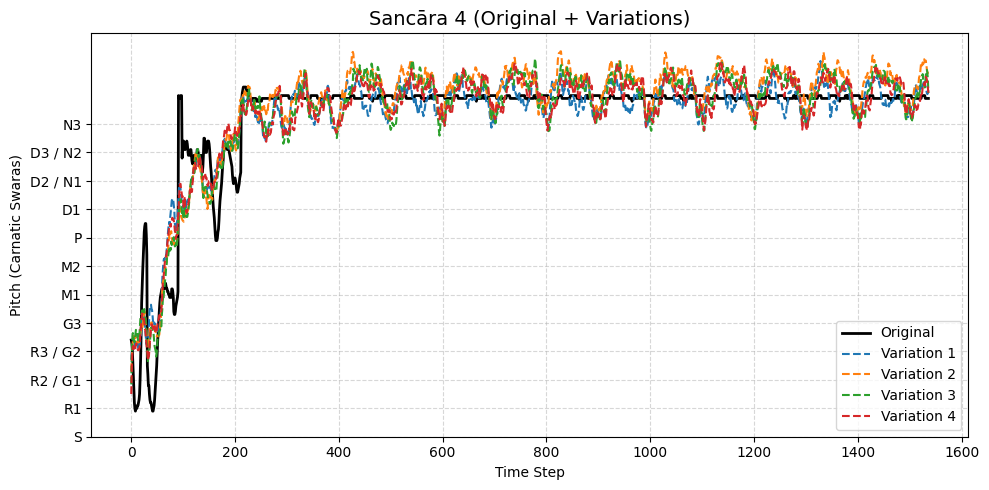

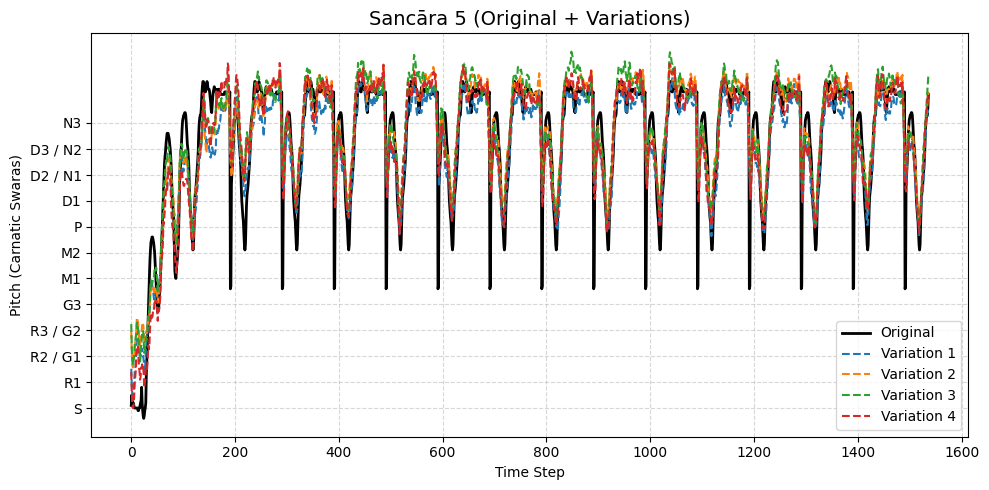

In [ ]:
import json
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence
from scipy.signal import savgol_filter

# ====================== Load and Normalize ======================
with open("/content/only_pitch_cents_grouped.json", "r") as file:
    raw_data = json.load(file)


def pad_with_last_100_pitches(sequences):
    max_len = max(len(seq) for seq in sequences)
    padded_sequences = []

    for seq in sequences:
        if len(seq) < max_len:
            last_100 = seq[-100:] if len(seq) >= 100 else seq  # If less than 100, take as much as possible
            repeats = (max_len - len(seq)) // len(last_100)
            remainder = (max_len - len(seq)) % len(last_100)

            padding = torch.cat([last_100] * repeats + [last_100[:remainder]])
            padded_seq = torch.cat([seq, padding])
        else:
            padded_seq = seq
        padded_sequences.append(padded_seq)

    return torch.stack(padded_sequences)

phrases = [torch.tensor([p for p in seq if p != 0], dtype=torch.float32) for seq in raw_data]
lengths = [len(p) for p in phrases]
max_len = max(lengths)
padded_phrases = pad_with_last_100_pitches(phrases)
mean = padded_phrases[padded_phrases != 0].mean()
std = padded_phrases[padded_phrases != 0].std()
padded_phrases = (padded_phrases - mean) / std

# ====================== Dataset ======================
class PhraseDataset(Dataset):
    def __init__(self, phrases):
        self.data = phrases

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = PhraseDataset(padded_phrases)

# ====================== VAE Model ======================
class VAE(nn.Module):
    def __init__(self, seq_len, hidden_dim=128, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(seq_len, hidden_dim),
            nn.ReLU(),
        )
        self.mu = nn.Linear(hidden_dim, latent_dim)
        self.logvar = nn.Linear(hidden_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, seq_len),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# ====================== Loss Function ======================
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.MSELoss()(recon_x, x)
    kl_div = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + 0.001 * kl_div  # Beta-VAE

# ====================== Train (Full-Batch) ======================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seq_len = padded_phrases.shape[1]
model = VAE(seq_len=seq_len).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

full_batch = padded_phrases.to(device)

model.train()
for epoch in range(100):
    recon, mu, logvar = model(full_batch)
    loss = vae_loss(recon, full_batch, mu, logvar)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# ====================== Helpers ======================
def smooth(seq, window=11, polyorder=3):
    if len(seq) < window:
        return seq
    return savgol_filter(seq, window_length=window, polyorder=polyorder)

def clip_pitch_range(seq, min_val=0, max_val=3000):
    return np.clip(seq, min_val, max_val)

# ====================== Generate Variations ======================
def generate_variation_from_phrase(model, input_tensor, num_variants=5, variation_strength=0.5):
    model.eval()
    input_tensor = input_tensor.to(device)
    with torch.no_grad():
        mu, logvar = model.encode(input_tensor.unsqueeze(0))
        variations = []
        for _ in range(num_variants):
            z = mu + variation_strength * torch.randn_like(mu)
            out = model.decode(z).squeeze(0)
            out = out.cpu().numpy() * std.item() + mean.item()
            out = smooth(out)
            out = clip_pitch_range(out)
            variations.append(out)
        return variations

import numpy as np
import matplotlib.pyplot as plt

# Function to map pitch values (in cents) to Carnatic music note names
def pitch_to_carnatic_note_name(pitch):
    """Convert pitch value in cents to Carnatic music note name."""
    # Note names based on standard Carnatic music notation
    cent_intervals = np.arange(0, 1200, 100)
    swaras = ['S', 'R1', 'R2 / G1', 'R3 / G2', 'G3', 'M1', 'M2', 'P', 'D1', 'D2 / N1', 'D3 / N2', 'N3']
    idx = int(round(pitch / 100))
    if 0 <= idx < len(swaras):
        return swaras[idx]
    return ''

# ====================== Plot Variations ======================
num_phrases_to_plot = 5  # Number of phrases to visualize

for idx in range(num_phrases_to_plot):
    input_phrase = dataset[idx]
    original = input_phrase.numpy() * std.item() + mean.item()
    variants = generate_variation_from_phrase(model, input_phrase, num_variants=4, variation_strength=0.4)

    plt.figure(figsize=(10, 5))
    plt.plot(original, label="Original", linewidth=2, color="black")
    for i, var in enumerate(variants):
        plt.plot(var, label=f"Variation {i+1}", linestyle="--")
    plt.title(f"Sancāra {idx + 1} (Original + Variations)", fontsize=14)
    plt.xlabel("Time Step")
    plt.ylabel("Pitch (Carnatic Swaras)")
        # Set Y-ticks every 100 cents with Carnatic swara labels
    y_ticks = np.arange(0, 1200, 100)
    y_labels = ['S', 'R1', 'R2 / G1', 'R3 / G2', 'G3', 'M1', 'M2', 'P', 'D1', 'D2 / N1', 'D3 / N2', 'N3']
    plt.yticks(y_ticks, y_labels)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()